## Importing the Necessary Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

## Loading the Dataset

In [4]:
df = pd.read_csv('bank.csv')
df

,age,job,marital,education,default,balance,housing-loan,personal-loan,current-campaign,previous-campaign,subscribed
0,30,unemployed,married,primary,no,1787,no,no,1,0,no
1,33,services,married,secondary,no,4789,yes,yes,1,4,no
2,35,management,single,tertiary,no,1350,yes,no,1,1,no
3,30,management,married,tertiary,no,1476,yes,yes,4,0,no
4,59,blue-collar,married,secondary,no,0,yes,no,1,0,no
...,...,...,...,...,...,...,...,...,...,...,...
4516,33,services,married,secondary,no,-333,yes,no,5,0,no
4517,57,self-employed,married,tertiary,yes,-3313,yes,yes,1,0,no
4518,57,technician,married,secondary,no,295,no,no,11,0,no
4519,28,blue-collar,married,secondary,no,1137,no,no,4,3,no


## Basic Info on the Dataset

In [6]:
df.shape

(4521, 11)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   age                4521 non-null   int64 
 1   job                4521 non-null   object
 2   marital            4521 non-null   object
 3   education          4521 non-null   object
 4   default            4521 non-null   object
 5   balance            4521 non-null   int64 
 6   housing-loan       4521 non-null   object
 7   personal-loan      4521 non-null   object
 8   current-campaign   4521 non-null   int64 
 9   previous-campaign  4521 non-null   int64 
 10  subscribed         4521 non-null   object
dtypes: int64(4), object(7)
memory usage: 388.7+ KB


In [8]:
df.describe()

,age,balance,current-campaign,previous-campaign
count,4521.000000,4521.000000,4521.000000,4521.000000
mean,41.170095,1422.657819,2.793630,0.542579
std,10.576211,3009.638142,3.109807,1.693562
min,19.000000,-3313.000000,1.000000,0.000000
25%,33.000000,69.000000,1.000000,0.000000
50%,39.000000,444.000000,2.000000,0.000000
75%,49.000000,1480.000000,3.000000,0.000000
max,87.000000,71188.000000,50.000000,25.000000


In [14]:
for i in df.columns:
    if df[i].dtype == 'object':
        print(df[i].value_counts())

job
management       969
blue-collar      946
technician       768
admin.           478
services         417
retired          230
self-employed    183
entrepreneur     168
unemployed       128
housemaid        112
student           84
unknown           38
Name: count, dtype: int64
marital
married     2797
single      1196
divorced     528
Name: count, dtype: int64
education
secondary    2306
tertiary     1350
primary       678
unknown       187
Name: count, dtype: int64
default
no     4445
yes      76
Name: count, dtype: int64
housing-loan
yes    2559
no     1962
Name: count, dtype: int64
personal-loan
no     3830
yes     691
Name: count, dtype: int64
subscribed
no     4000
yes     521
Name: count, dtype: int64


In [16]:
df[df['subscribed'] == 'no']['balance'].mean()

1403.21175

In [18]:
df[df['subscribed'] == 'no']['balance'].median()

419.5

In [20]:
df[df['subscribed'] == 'yes']['balance'].mean()

1571.9558541266795

In [22]:
df[df['subscribed'] == 'yes']['balance'].median()

710.0

### Train Test Split

In [25]:
from sklearn.model_selection import train_test_split

In [27]:
x_train, x_test, y_train, y_test = train_test_split(df.iloc[:,:-1], df.iloc[:,-1], test_size = 0.3, random_state = 22107)

In [29]:
print(y_train.value_counts())
print(y_test.value_counts())

subscribed
no     2792
yes     372
Name: count, dtype: int64
subscribed
no     1208
yes     149
Name: count, dtype: int64


In [31]:
y_test

983      no
2797     no
3261     no
2375    yes
909      no
       ... 
3672     no
4431     no
3196     no
773      no
3776     no
Name: subscribed, Length: 1357, dtype: object

In [33]:
y_train

1356    no
107     no
2990    no
1591    no
1538    no
        ..
243     no
547     no
1275    no
2342    no
1806    no
Name: subscribed, Length: 3164, dtype: object

In [35]:
x_train

,age,job,marital,education,default,balance,housing-loan,personal-loan,current-campaign,previous-campaign
1356,30,management,single,tertiary,no,604,no,yes,1,0
107,33,self-employed,married,tertiary,no,483,yes,no,2,0
2990,56,blue-collar,married,primary,no,828,yes,no,1,1
1591,70,retired,married,secondary,no,2815,no,no,2,1
1538,50,blue-collar,divorced,secondary,no,203,yes,no,1,4
...,...,...,...,...,...,...,...,...,...,...
243,27,admin.,married,secondary,no,-247,yes,yes,2,0
547,54,management,married,tertiary,no,0,no,no,5,0
1275,41,blue-collar,married,secondary,no,-217,yes,no,1,3
2342,39,blue-collar,married,primary,no,385,yes,no,4,0


In [36]:
x_test

,age,job,marital,education,default,balance,housing-loan,personal-loan,current-campaign,previous-campaign
983,37,technician,divorced,secondary,no,79,no,no,1,0
2797,30,management,single,tertiary,no,18,no,no,11,0
3261,32,blue-collar,married,primary,no,66,no,no,1,0
2375,26,unemployed,single,secondary,no,622,no,no,2,0
909,34,entrepreneur,married,secondary,no,-139,yes,yes,2,0
...,...,...,...,...,...,...,...,...,...,...
3672,45,blue-collar,married,secondary,no,4022,yes,no,3,0
4431,37,blue-collar,married,primary,no,190,yes,yes,1,0
3196,46,self-employed,married,tertiary,no,137,yes,yes,1,0
773,33,unemployed,married,secondary,no,2,yes,no,1,0


### Encoding the Dataset

#### Target Column using Label Encoder

In [39]:
from sklearn.preprocessing import LabelEncoder

In [41]:
le = LabelEncoder()
le.fit(y_train)

LabelEncoder()

In [43]:
y_train = le.transform(y_train)
y_train = pd.DataFrame(y_train, columns = ['subscribed'])
y_train

,subscribed
0,0
1,0
2,0
3,0
4,0
...,...
3159,0
3160,0
3161,0
3162,0


In [45]:
y_test = le.transform(y_test)
y_test = pd.DataFrame(y_test, columns = ['subscribed'])
y_test

,subscribed
0,0
1,0
2,0
3,1
4,0
...,...
1352,0
1353,0
1354,0
1355,0


#### Independent Variables using get_dummies

In [47]:
x_train = pd.get_dummies(x_train, drop_first = True, dtype = 'int')
x_train.index = range(len(x_train))
x_train

,age,balance,current-campaign,previous-campaign,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,...,job_unemployed,job_unknown,marital_married,marital_single,education_secondary,education_tertiary,education_unknown,default_yes,housing-loan_yes,personal-loan_yes
0,30,604,1,0,0,0,0,1,0,0,...,0,0,0,1,0,1,0,0,0,1
1,33,483,2,0,0,0,0,0,0,1,...,0,0,1,0,0,1,0,0,1,0
2,56,828,1,1,1,0,0,0,0,0,...,0,0,1,0,0,0,0,0,1,0
3,70,2815,2,1,0,0,0,0,1,0,...,0,0,1,0,1,0,0,0,0,0
4,50,203,1,4,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3159,27,-247,2,0,0,0,0,0,0,0,...,0,0,1,0,1,0,0,0,1,1
3160,54,0,5,0,0,0,0,1,0,0,...,0,0,1,0,0,1,0,0,0,0
3161,41,-217,1,3,1,0,0,0,0,0,...,0,0,1,0,1,0,0,0,1,0
3162,39,385,4,0,1,0,0,0,0,0,...,0,0,1,0,0,0,0,0,1,0


In [49]:
X = pd.concat([x_train, y_train], axis = 1)
X.subscribed.value_counts()

subscribed
0    2792
1     372
Name: count, dtype: int64

### resampling

In [51]:
X_minority = X[X.subscribed == 1]
X_minority

,age,balance,current-campaign,previous-campaign,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,...,job_unknown,marital_married,marital_single,education_secondary,education_tertiary,education_unknown,default_yes,housing-loan_yes,personal-loan_yes,subscribed
23,31,4148,3,9,0,0,0,1,0,0,...,0,1,0,0,1,0,0,1,0,1
24,37,393,3,4,0,0,0,1,0,0,...,0,1,0,0,1,0,0,1,0,1
31,31,1224,2,0,0,0,0,1,0,0,...,0,1,0,0,1,0,0,1,1,1
34,32,2431,5,0,0,0,0,1,0,0,...,0,1,0,0,1,0,0,1,0,1
37,59,351,5,0,0,0,0,0,1,0,...,0,0,1,1,0,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3138,48,7195,2,0,0,0,1,0,0,0,...,0,1,0,0,0,0,0,0,0,1
3140,37,480,2,8,0,0,0,0,0,0,...,0,1,0,1,0,0,0,0,0,1
3141,84,639,3,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
3147,55,1580,1,0,0,0,0,0,1,0,...,0,0,0,1,0,0,0,0,1,1


In [53]:
X_majority = X[X.subscribed == 0]
X_majority

,age,balance,current-campaign,previous-campaign,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,...,job_unknown,marital_married,marital_single,education_secondary,education_tertiary,education_unknown,default_yes,housing-loan_yes,personal-loan_yes,subscribed
0,30,604,1,0,0,0,0,1,0,0,...,0,0,1,0,1,0,0,0,1,0
1,33,483,2,0,0,0,0,0,0,1,...,0,1,0,0,1,0,0,1,0,0
2,56,828,1,1,1,0,0,0,0,0,...,0,1,0,0,0,0,0,1,0,0
3,70,2815,2,1,0,0,0,0,1,0,...,0,1,0,1,0,0,0,0,0,0
4,50,203,1,4,1,0,0,0,0,0,...,0,0,0,1,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3159,27,-247,2,0,0,0,0,0,0,0,...,0,1,0,1,0,0,0,1,1,0
3160,54,0,5,0,0,0,0,1,0,0,...,0,1,0,0,1,0,0,0,0,0
3161,41,-217,1,3,1,0,0,0,0,0,...,0,1,0,1,0,0,0,1,0,0
3162,39,385,4,0,1,0,0,0,0,0,...,0,1,0,0,0,0,0,1,0,0


In [55]:
from sklearn.utils import resample

In [57]:
X_minority_upsampled = resample(X_minority, replace = True, n_samples = 2000, random_state = 22107)

In [58]:
X_majority_downsampled = resample(X_majority, replace = True, n_samples = 2000, random_state = 22107)

In [59]:
X = pd.concat([X_minority_upsampled, X_majority_downsampled])
X

,age,balance,current-campaign,previous-campaign,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,...,job_unknown,marital_married,marital_single,education_secondary,education_tertiary,education_unknown,default_yes,housing-loan_yes,personal-loan_yes,subscribed
2368,55,3334,4,0,0,0,0,0,1,0,...,0,1,0,0,0,0,0,0,0,1
2058,52,2227,2,0,0,0,0,0,0,0,...,0,0,1,0,0,1,0,0,0,1
2587,36,1133,1,2,0,0,0,1,0,0,...,0,1,0,0,1,0,0,1,0,1
2172,33,-416,2,0,1,0,0,0,0,0,...,0,0,1,1,0,0,0,1,0,1
590,32,1905,2,0,1,0,0,0,0,0,...,0,1,0,1,0,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
887,35,1350,1,1,0,0,0,1,0,0,...,0,0,1,0,1,0,0,1,0,0
420,55,481,2,3,0,0,0,1,0,0,...,0,0,0,0,1,0,0,1,0,0
1146,37,4039,2,0,0,0,0,1,0,0,...,0,1,0,0,1,0,0,0,1,0
360,33,5137,1,0,1,0,0,0,0,0,...,0,0,1,1,0,0,0,1,0,0


In [63]:
x_train = X.iloc[:,:-1]
y_train = X.iloc[:, -1]

In [65]:
x_test = pd.get_dummies(x_test, drop_first = True, dtype = 'int')
x_test

,age,balance,current-campaign,previous-campaign,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,...,job_unemployed,job_unknown,marital_married,marital_single,education_secondary,education_tertiary,education_unknown,default_yes,housing-loan_yes,personal-loan_yes
983,37,79,1,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
2797,30,18,11,0,0,0,0,1,0,0,...,0,0,0,1,0,1,0,0,0,0
3261,32,66,1,0,1,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
2375,26,622,2,0,0,0,0,0,0,0,...,1,0,0,1,1,0,0,0,0,0
909,34,-139,2,0,0,1,0,0,0,0,...,0,0,1,0,1,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3672,45,4022,3,0,1,0,0,0,0,0,...,0,0,1,0,1,0,0,0,1,0
4431,37,190,1,0,1,0,0,0,0,0,...,0,0,1,0,0,0,0,0,1,1
3196,46,137,1,0,0,0,0,0,0,1,...,0,0,1,0,0,1,0,0,1,1
773,33,2,1,0,0,0,0,0,0,0,...,1,0,1,0,1,0,0,0,1,0


## Dimensionality Reduction

In [68]:
from sklearn.decomposition import PCA

In [69]:
pca = PCA(n_components = 6, whiten = True)

In [72]:
pca.fit(x_train)

PCA(n_components=6, whiten=True)

In [73]:
x_train = pca.transform(x_train)
x_test = pca.transform(x_test)

## Logistic Regression

In [77]:
from sklearn.linear_model import LogisticRegression

In [79]:
model = LogisticRegression(max_iter = 100000)
model.fit(x_train, y_train)

LogisticRegression(max_iter=100000)

In [81]:
pred = model.predict(x_test)
pred

array([0, 0, 0, ..., 0, 0, 0])

In [83]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score

In [85]:
print(classification_report(y_test, pred))
print(confusion_matrix(y_test, pred))

              precision    recall  f1-score   support

           0       0.92      0.67      0.78      1208
           1       0.17      0.56      0.26       149

    accuracy                           0.66      1357
   macro avg       0.55      0.62      0.52      1357
weighted avg       0.84      0.66      0.72      1357

[[813 395]
 [ 66  83]]


In [87]:
auc = roc_auc_score(y_test, model.predict_proba(x_test)[:,1])
auc

0.6715687363882838

### Using GridSearchCV

In [90]:
from sklearn.model_selection import GridSearchCV

In [96]:
params = {'penalty': ['l1', 'l2'], 'C': range(1,50), 'solver': ['lbfgs', 'liblinear']}
model_gs = LogisticRegression(max_iter = 100000)
log_gs = GridSearchCV(model_gs, params, cv = 5, scoring = 'roc_auc')
log_gs.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=100000),
             param_grid={'C': range(1, 50), 'penalty': ['l1', 'l2'],
                         'solver': ['lbfgs', 'liblinear']},
             scoring='roc_auc')

In [98]:
log_gs.best_params_

{'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}

In [100]:
log_gs.best_score_

0.6716362499999999

In [102]:
log_bp = LogisticRegression(C = 1, penalty = 'l1', solver = 'liblinear', max_iter = 100000)
log_bp.fit(x_train, y_train)

LogisticRegression(C=1, max_iter=100000, penalty='l1', solver='liblinear')

In [112]:
pred_bp = log_bp.predict(x_test)
pred_proba = log_bp.predict_proba(x_test)[:,1]
pred_bp

array([0, 0, 0, ..., 0, 0, 0])

In [114]:
print(classification_report(y_test, pred_bp))

              precision    recall  f1-score   support

           0       0.93      0.67      0.78      1208
           1       0.17      0.56      0.27       149

    accuracy                           0.66      1357
   macro avg       0.55      0.62      0.52      1357
weighted avg       0.84      0.66      0.72      1357



In [116]:
print(confusion_matrix(y_test, pred_bp))

[[814 394]
 [ 66  83]]


In [118]:
auc = roc_auc_score(y_test, pred_proba)
auc

0.671618738610605

### Roc Auc Curve

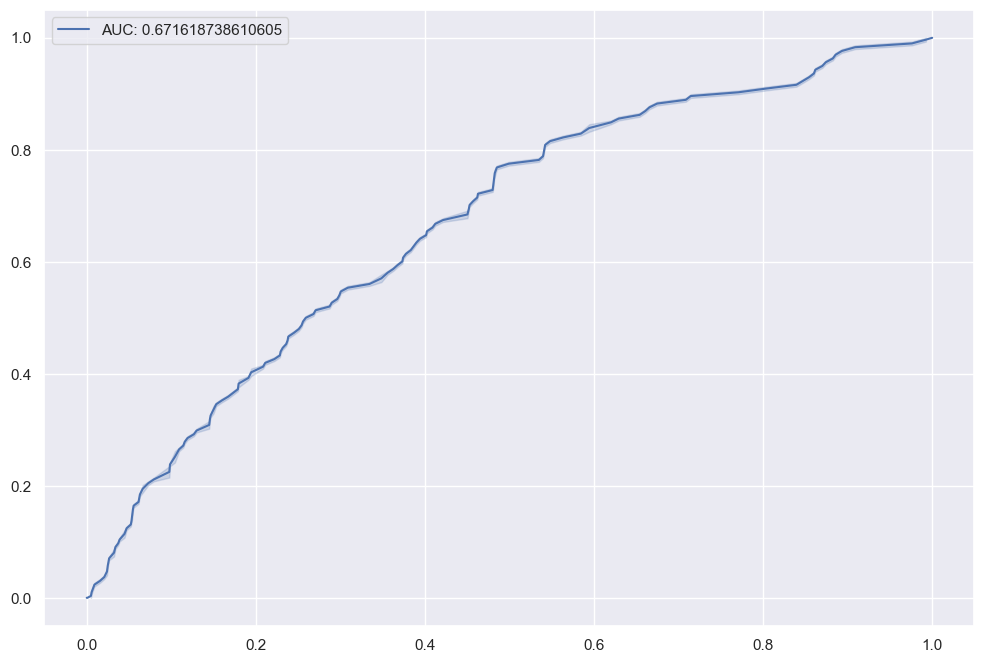

In [121]:
fpr, tpr, thresholds = roc_curve(y_test, pred_proba)
plt.figure(figsize = (12, 8))
sns.lineplot(x = fpr, y = tpr, label = 'AUC: '+str(auc))
plt.show()